In [2]:
#| output: false
import sys
sys.path.append('..')
from Edinburgh_Model.model import *

from numpy import linspace, pi, log, arange
from scipy.stats import vonmises
import matplotlib.pyplot as plt

pars = Parameters()

p = 0.95

pars.season_width = 0.11 # estimated value from Dicko et al 2024 (see notebook S7)
x = linspace(-pi, pi, 100)
d = vonmises(kappa=-log(pars.season_width), loc=0)
pdf = d.pdf(x)
cdf = d.cdf(x)

scale = 12 / (2 * pi)
season_start = d.ppf((1-p)/2)
season_end = d.ppf((1+p)/2)


We use the circular von Mises distribution to model seasonal changes in transmission rate. The Von Mises distribution for angle $\theta$ is given by

$$f(\theta\mid \mu, \kappa) \propto \exp(\kappa\cos(\theta-\mu))$$

where $\mu$ is the angle at the peak of the distribution. We place the peak of the season at week $S_\text{peak}$ relative to last primary vaccination. $\kappa$ is a measure of the concentration of probability around $\mu$. $\kappa=0$ corresponds to a uniform circular distribution. Let $S_\text{width}=e^{-\kappa}\in[0, 1]$. $S_\text{width}=1$ corresponds to no seasonality (i.e., constant transmission rate through time), and as $S_\text{width}$ approaches zero the malaria season becomes shorter.

Therefore, the blood infection rate, $\lambda$, in week $t$ post last primary vaccination is modified by the factor

$$\frac{\exp\left(-\ln (S_\text{width}) \cos\left(2\pi\left[\frac{t-S_\text{peak}+26}{52}\right] \right)\right)}{Z}$$

where $Z=\sum_{i=0}^{51}\exp\left(-\ln (S_\text{width}) \cos\left(2\pi\left[\frac{t-S_\text{peak}+26}{52}\right] \right)\right)$ is a normalisation factor.

@roca-feltrer_simple_2009 defined "marked seasonality" if 75% or more of all episodes occurred in six or less months of the year. We define the length of the malaria season as the minimum number of months that contain 95% of the total malaria cases.

This definition only holds when there is a well de-marked malaria season. 

The blue line in @fig-fig1 shows the transmission rate modification factor for a value of $S_\text{width}=$ `{python} pars.season_width`, which was estimated from the phase 3 RTS,S and SMC trial in @dicko_seasonal_2024 ([Notebook S8](S8_SMC.ipynb)). This results in a season length of `{python} f'{(season_end - season_start) * scale:.1f}'` months according to our definition. The malaria season is represented by the grey region which contains 95% of cases. 

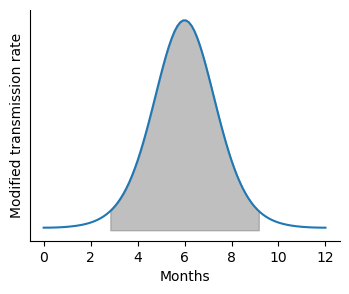

In [3]:
#| label: fig-fig1
#| fig-cap: "The modified transmission rate (blue line). 95% of infections occur within the grey area."

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot((x+pi) * scale, pdf, label='')
xx = linspace(season_start, season_end, 100)
ax.fill_between((xx+pi) * scale, d.pdf(xx), color='gray', alpha=0.5, label='Season length')
ax.set_xlabel('Months')
ax.set_ylabel('Modified transmission rate')
ax.set_yticks([]);
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


@fig-fig2 shows how season length (as defined above) changes for different values of $S_\text{width}$.

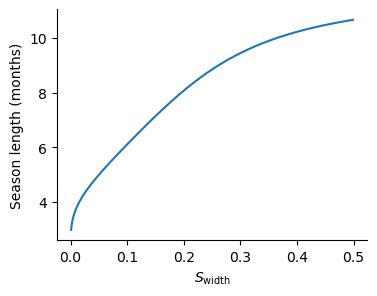

In [4]:
#| label: fig-fig2
#| fig-cap: "A line plot "

p = 0.95

k = arange(0.001, 0.5, 0.001)
l = []
for ki in k:
    d = vonmises(kappa=-log(ki), loc=0)
    l.append(12 / pi * d.ppf((1+p)/2))

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(k, l)
ax.set_xlabel(r'$S_\text{width}$')
ax.set_ylabel(f'Season length (months)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


::: {#refs}
:::